In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Period

In [2]:
iyear=1960
fyear=2024
nx=10;ny=10
dom='GRq'
dom_NST = 'GRc'
year_NST = '2000'

# Elevation data

In [3]:
ds_grM= xr.open_dataset(f'/home/santolam/NST.{year_NST}.01.01.00.{dom_NST}.nc')
LONS=ds_grM.LON[ny:-ny,nx:-nx].values
LATS=ds_grM.LAT[ny:-ny,nx:-nx].values
dsSH=ds_grM.SH[ny:-ny,nx:-nx]
latS=LATS.min(); latN=LATS.max()
lonW=LONS.min(); lonE=LONS.max()

elev = dsSH
elev = elev.rename({'x': 'X', 'y': 'Y'})

# SF & RF & TF Data

In [4]:
RF = xr.open_mfdataset(f'/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/{dom}/spin2/work/monthly/RF_monsum_MARv3.14_ER5_spin2_{dom}_*.nc',
                       combine="by_coords")['RF']
RF = RF.rename({'TIME': 'time'})
RF = RF[:,ny:-ny,nx:-nx].sel(time=slice(f"{iyear}-01-01", f"{fyear}-12-31"))

SF = xr.open_mfdataset(f'/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/{dom}/spin2/work/monthly/SF_monsum_MARv3.14_ER5_spin2_{dom}_*.nc',
                       combine="by_coords")['SF']
SF = SF.rename({'TIME': 'time'})
SF = SF[:,ny:-ny,nx:-nx].sel(time=slice(f"{iyear}-01-01", f"{fyear}-12-31"))


#Compute Total Rainfall
TF = RF + SF

# ICE mask

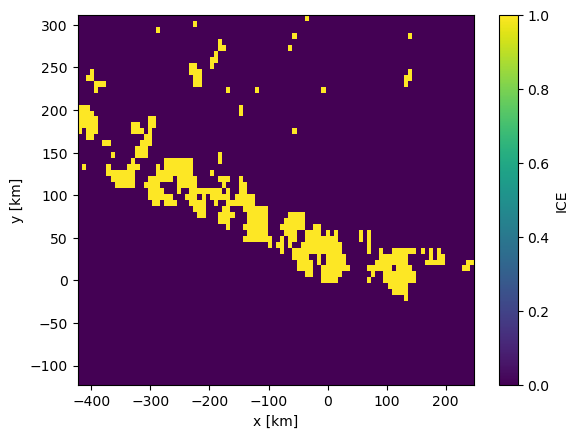

In [5]:
dsICE = ds_grM.ICE[ny:-ny,nx:-nx]
ICE_mask = dsICE > 0
ICE_mask = ICE_mask.rename({'x': 'X', 'y': 'Y'})
ICE_mask.plot()

In [6]:
ICE_mask = ICE_mask.assign_coords({
    "X": RF.X,
    "Y": RF.Y
})
RF = RF.where(ICE_mask)

ICE_mask = ICE_mask.assign_coords({
    "X": SF.X,
    "Y": SF.Y
})
SF = SF.where(ICE_mask)

ICE_mask = ICE_mask.assign_coords({
    "X": TF.X,
    "Y": TF.Y
})
TF = TF.where(ICE_mask)

# Mean over period

In [7]:
SF_mean = SF.mean('time', skipna=True)

RF_mean = RF.mean('time', skipna=True)

TF_mean = TF.mean('time', skipna=True)

# Mean per elevation bands (step = 250 m)

In [8]:
# Altitude bands per 250 m
elev_bands = np.arange(3250, 6501, 250)

#Grille pas exactement les mêmes valeurs des fois à ,e-5 près 
elev = elev.assign_coords({
    "X": RF.X,
    "Y": RF.Y
})

# RF mean per band of 250 m
RF_bands = RF_mean.groupby_bins(elev, bins=elev_bands).mean()

In [9]:
#Grille pas exactement les mêmes valeurs des fois à ,e-5 près 
elev = elev.assign_coords({
    "X": SF.X,
    "Y": SF.Y
})

# RF mean per band of 250 m
SF_bands = SF_mean.groupby_bins(elev, bins=elev_bands).mean()

In [10]:
#Grille pas exactement les mêmes valeurs des fois à ,e-5 près 
elev = elev.assign_coords({
    "X": TF.X,
    "Y": TF.Y
})

# RF mean per band of 250 m
TF_bands = TF_mean.groupby_bins(elev, bins=elev_bands).mean()

In [11]:
R_bands = RF_bands / SF_bands * 100

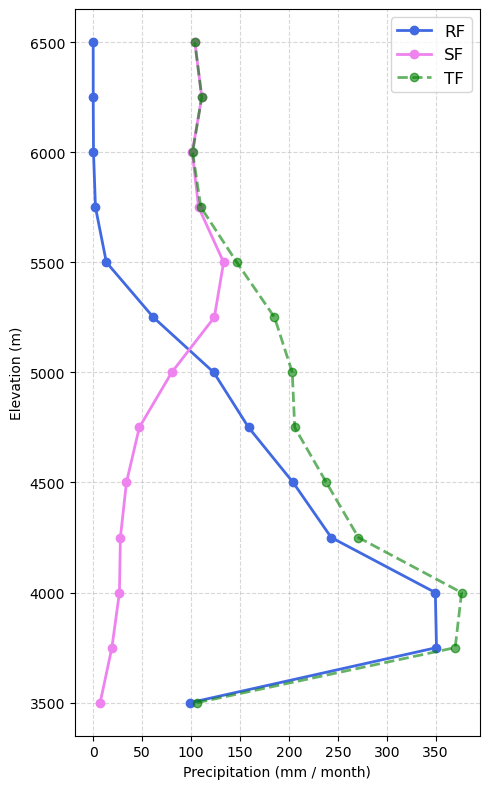

In [12]:
y = [interval.right for interval in RF_bands.SH_bins.values]

fig, ax = plt.subplots(figsize=(5,8))

ax.plot(
    RF_bands.values, y, 
    marker='o', 
    linestyle='-',
    color='royalblue',
    label=f'RF',
    linewidth=2)

ax.plot(
    SF_bands.values, y, 
    marker='o', 
    linestyle='-',
    color='violet',
    label=f'SF',
    linewidth=2)

ax.plot(
    TF_bands.values, y, 
    marker='o', 
    linestyle='--',
    color='green',
    label=f'TF',
    linewidth=2, alpha = 0.6)

ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.legend(fontsize=12)

ax.set_xlabel('Precipitation (mm / month)')
ax.set_ylabel('Elevation (m)')

plt.tight_layout()
plt.show()

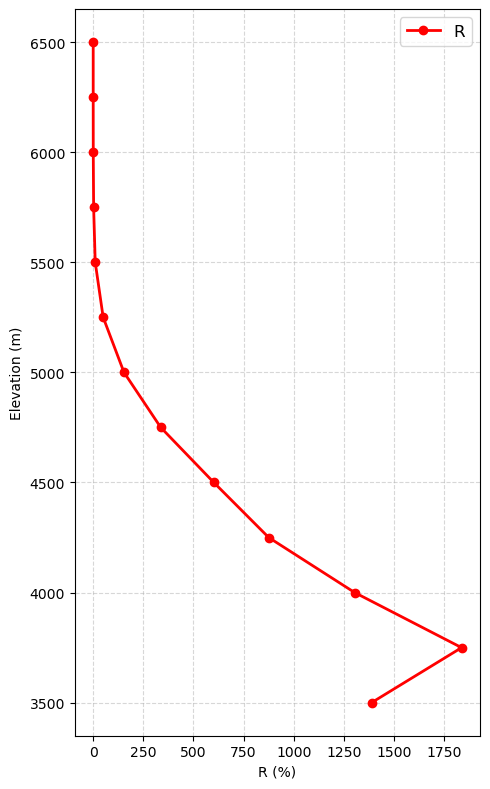

In [13]:
fig, ax = plt.subplots(figsize=(5,8))

ax.plot(
    R_bands.values, y, 
    marker='o', 
    linestyle='-',
    color='red',
    label=f'R',
    linewidth=2)

ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.legend(fontsize=12)

ax.set_xlabel('R (%)')
ax.set_ylabel('Elevation (m)')

plt.tight_layout()
plt.show()

# Monthly mean vertical profile

In [14]:
SF_monthly_mean = SF.groupby('time.month').mean('time', skipna=True)

RF_monthly_mean = RF.groupby('time.month').mean('time', skipna=True)

TF_monthly_mean = TF.groupby('time.month').mean('time', skipna=True)

In [15]:
# Altitude bands per 250 m
elev_bands = np.arange(3250, 6501, 250)

#Grille pas exactement les mêmes valeurs des fois à ,e-5 près 
elev = elev.assign_coords({
    "X": RF.X,
    "Y": RF.Y
})

# RF mean per band of 250 m
RF_monthly_bands = RF_monthly_mean.groupby_bins(elev, bins=elev_bands).mean()

In [16]:
#Grille pas exactement les mêmes valeurs des fois à ,e-5 près 
elev = elev.assign_coords({
    "X": SF.X,
    "Y": SF.Y
})

# SF mean per band of 250 m
SF_monthly_bands = SF_monthly_mean.groupby_bins(elev, bins=elev_bands).mean()

In [17]:
#Grille pas exactement les mêmes valeurs des fois à ,e-5 près 
elev = elev.assign_coords({
    "X": TF.X,
    "Y": TF.Y
})

# TF mean per band of 250 m
TF_monthly_bands = TF_monthly_mean.groupby_bins(elev, bins=elev_bands).mean()

In [18]:
R_monthly_bands = RF_monthly_bands / SF_monthly_bands * 100

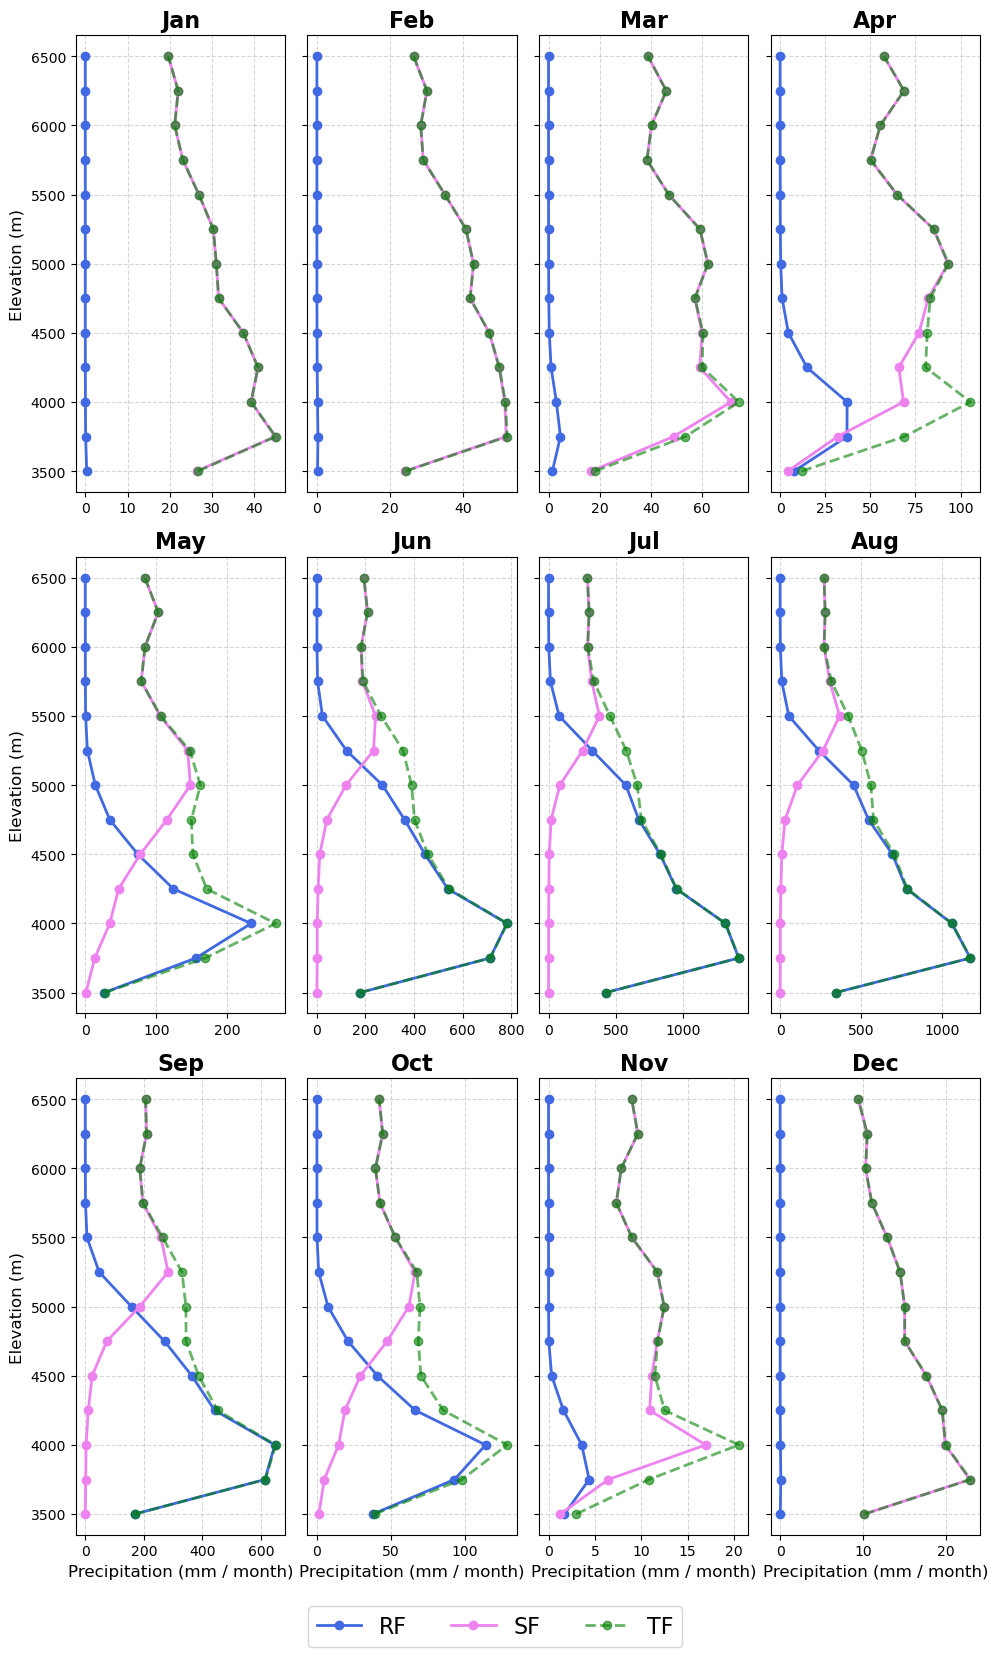

In [19]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
y = [interval.right for interval in RF_monthly_bands.SH_bins.values]

fig, axes = plt.subplots(3, 4,figsize=(10, 16))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.plot(
        RF_monthly_bands.sel(month=i+1).values, y, 
        marker='o', 
        linestyle='-',
        color='royalblue',
        label=f'RF',
        linewidth=2)
    
    ax.plot(
        SF_monthly_bands.sel(month=i+1).values, y, 
        marker='o', 
        linestyle='-',
        color='violet',
        label=f'SF',
        linewidth=2)
    
    ax.plot(
        TF_monthly_bands.sel(month=i+1).values, y, 
        marker='o', 
        linestyle='--',
        color='green',
        label=f'TF',
        linewidth=2, alpha = 0.6)
    
    ax.set_title(months[i], fontsize=16, weight="bold")
    
    if i in [0, 4, 8]:  # colonne gauche
        ax.set_ylabel('Elevation (m)', fontsize=12)
    else:
        ax.tick_params(labelleft=False)
        
    if i in [8, 9, 10, 11]:  # ligne du bas
        ax.set_xlabel('Precipitation (mm / month)', fontsize=12)
    
    ax.grid(True, linestyle='--', alpha=0.5, zorder=0)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)    

plt.tight_layout()
plt.show()

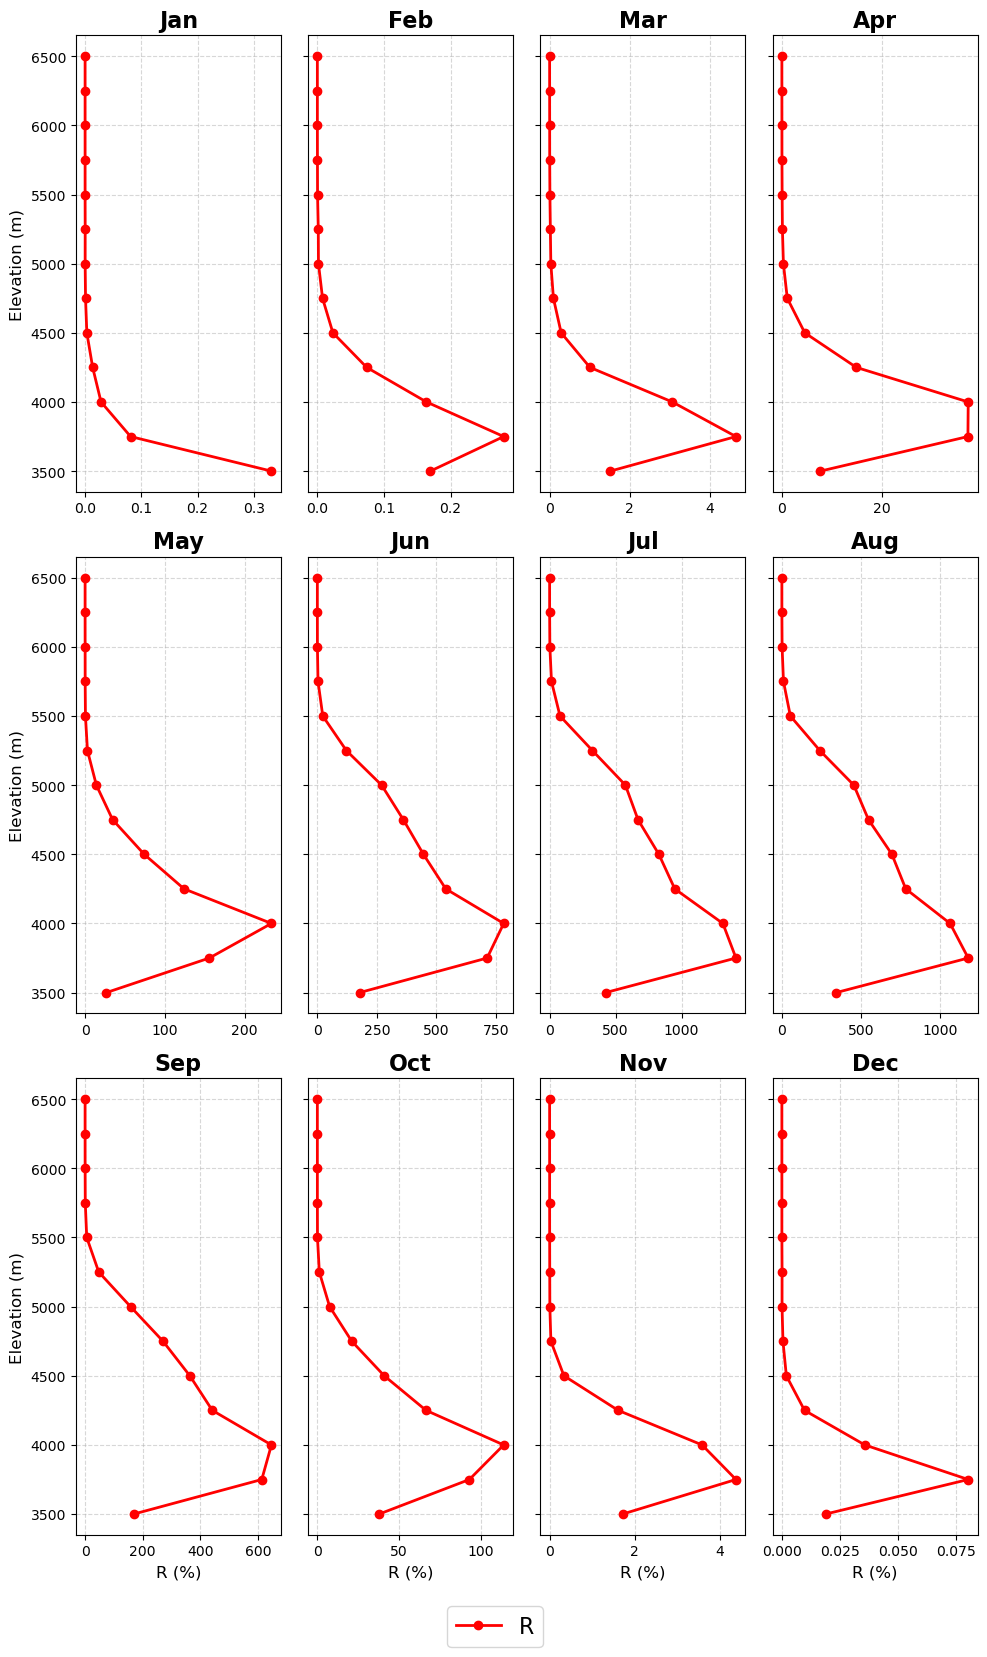

In [20]:
fig, axes = plt.subplots(3, 4,figsize=(10, 16))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.plot(
        RF_monthly_bands.sel(month=i+1).values, y, 
        marker='o', 
        linestyle='-',
        color='red',
        label=f'R',
        linewidth=2)
    
    ax.set_title(months[i], fontsize=16, weight="bold")
    
    if i in [0, 4, 8]:  # colonne gauche
        ax.set_ylabel('Elevation (m)', fontsize=12)
    else:
        ax.tick_params(labelleft=False)
        
    if i in [8, 9, 10, 11]:  # ligne du bas
        ax.set_xlabel('R (%)', fontsize=12)
    
    ax.grid(True, linestyle='--', alpha=0.5, zorder=0)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)    

plt.tight_layout()
plt.show()